In [1]:
from sklearn.datasets import make_blobs
from sklearn.manifold import TSNE
# import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Generate sample data with 3 clusters
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# t-SNE transformation
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# UMAP transformation
# umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
# X_umap = umap_model.fit_transform(X)




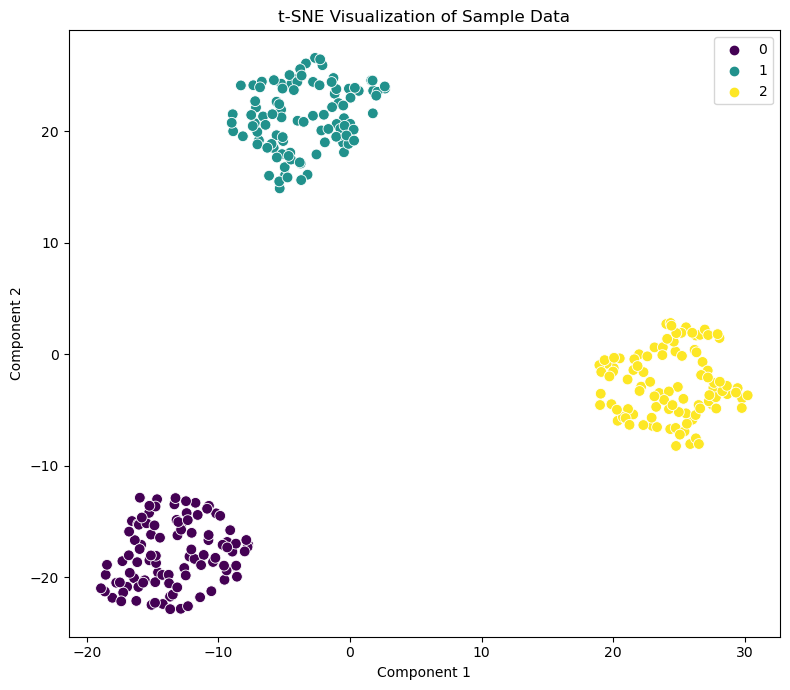

In [2]:
# Plotting
fig, axes = plt.subplots(1, 1, figsize=(8, 7))

# t-SNE plot
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="viridis", ax=axes, s=60, legend="full")
axes.set_title('t-SNE Visualization of Sample Data')
axes.set_xlabel('Component 1')
axes.set_ylabel('Component 2')

# # UMAP plot
# sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette="viridis", ax=axes[1], s=60, legend="full")
# axes[1].set_title('UMAP Visualization of Sample Data')
# axes[1].set_xlabel('Component 1')
# axes[1].set_ylabel('Component 2')

plt.tight_layout()
plt.show()

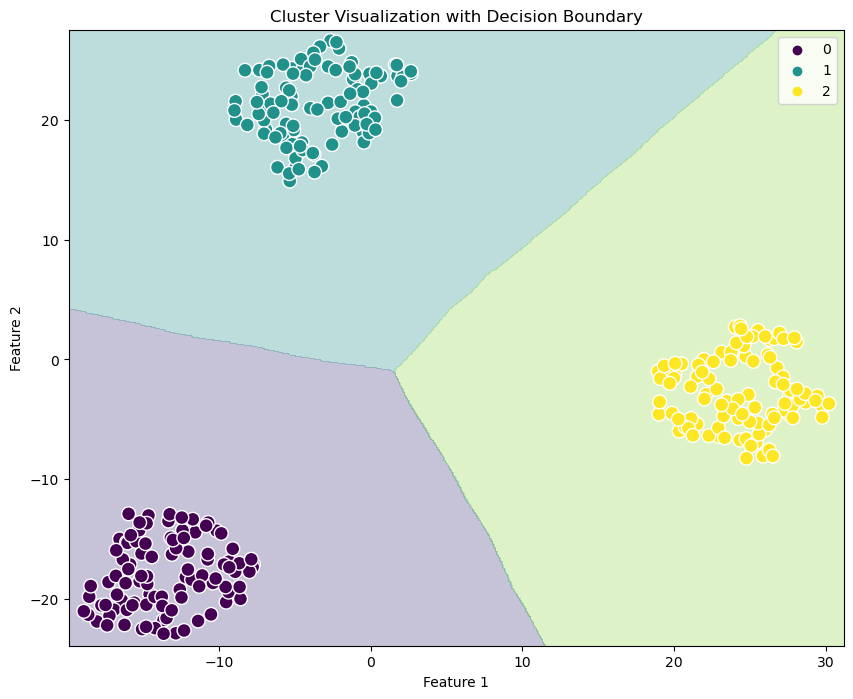

In [3]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Generating a simpler dataset
# X, y = make_blobs(n_samples=150, centers=3, cluster_std=0.5, random_state=0)
# X_tsne = tsne.fit_transform(X)
X = X_tsne

# Fit a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

# Create a mesh to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict classifications for each point in the mesh
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Generate the plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(len(np.unique(y))+1)-0.5, cmap="viridis")
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="viridis", s=100, edgecolor="w", linewidth=1)
plt.title('Cluster Visualization with Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
